# SVM Final Analysis


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.svm import SVC, LinearSVC
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline

DATA = 'smartphone+based+recognition+of+human+activities+and+postural+transitions'
RNG = 42

## Load data


In [10]:
X_train = pd.read_csv(f'{DATA}/Train/X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv(f'{DATA}/Train/y_train.txt', sep=r'\s+', header=None)[0]
X_test  = pd.read_csv(f'{DATA}/Test/X_test.txt',  sep=r'\s+', header=None)
y_test  = pd.read_csv(f'{DATA}/Test/y_test.txt',  sep=r'\s+', header=None)[0]

labels = pd.read_csv(f'{DATA}/activity_labels.txt', sep=r'\s+', header=None)
activity_map = dict(zip(labels[0], labels[1]))
y_train_m = y_train.map(activity_map)
y_test_m  = y_test.map(activity_map)

feat_names = pd.read_csv(f'{DATA}/features.txt', sep=r'\s+', header=None)[0].tolist()
X_train.columns = feat_names
X_test.columns  = feat_names

class_order = [activity_map[i] for i in sorted(activity_map.keys())]
print(X_train.shape, X_test.shape)

(7767, 561) (3162, 561)


## Feature subsets

Build a gravity / Z-axis / orientation subset to test the hypothesis from the progress report.


In [11]:
gravity_z_feats = [f for f in feat_names if
    'Gravity' in f or
    'gravity' in f or
    '-Z' in f or
    'angle(' in f
]
print(f'Gravity/Z subset: {len(gravity_z_feats)} features')
print('Sample:', gravity_z_feats[:10])
print('Total features available:', len(feat_names))
print('First 5 raw feature names:', feat_names[:5])

Gravity/Z subset: 60 features
Sample: ['tGravityAcc-Mean-1', 'tGravityAcc-Mean-2', 'tGravityAcc-Mean-3', 'tGravityAcc-STD-1', 'tGravityAcc-STD-2', 'tGravityAcc-STD-3', 'tGravityAcc-Mad-1', 'tGravityAcc-Mad-2', 'tGravityAcc-Mad-3', 'tGravityAcc-Max-1']
Total features available: 561
First 5 raw feature names: ['tBodyAcc-Mean-1', 'tBodyAcc-Mean-2', 'tBodyAcc-Mean-3', 'tBodyAcc-STD-1', 'tBodyAcc-STD-2']


## Ablation study

Metric = macro-F1 (minority classes matter).


In [12]:
def run(name, pipeline, Xtr, ytr, Xte, yte):
    t0 = time.time()
    pipeline.fit(Xtr, ytr)
    fit_t = time.time() - t0
    yp = pipeline.predict(Xte)
    return {
        'config': name,
        'macro_f1': f1_score(yte, yp, average='macro'),
        'weighted_f1': f1_score(yte, yp, average='weighted'),
        'accuracy': (yp == yte).mean(),
        'fit_sec': round(fit_t, 1),
    }

results = []

# kernel comparison (all with PCA-95%, balanced)
for kernel in ['linear', 'poly', 'rbf']:
    p = Pipeline([
        ('sc', StandardScaler()),
        ('pca', PCA(n_components=0.95, random_state=RNG)),
        ('svm', SVC(kernel=kernel, C=10, class_weight='balanced', random_state=RNG))
    ])
    results.append(run(f'{kernel}_pca95_bal', p, X_train, y_train_m, X_test, y_test_m))
    print(results[-1])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [13]:
# PCA dimensionality
for n in [0.90, 0.95, 0.99, None]:
    steps = [('sc', StandardScaler())]
    tag = 'raw561' if n is None else f'pca{int(n*100)}'
    if n is not None:
        steps.append(('pca', PCA(n_components=n, random_state=RNG)))
    steps.append(('svm', SVC(kernel='rbf', C=10, class_weight='balanced', random_state=RNG)))
    p = Pipeline(steps)
    results.append(run(f'rbf_{tag}_bal', p, X_train, y_train_m, X_test, y_test_m))
    print(results[-1])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [14]:
# class weighting
for cw in [None, 'balanced']:
    p = Pipeline([
        ('sc', StandardScaler()),
        ('pca', PCA(n_components=0.95, random_state=RNG)),
        ('svm', SVC(kernel='rbf', C=10, class_weight=cw, random_state=RNG))
    ])
    results.append(run(f'rbf_pca95_cw={cw}', p, X_train, y_train_m, X_test, y_test_m))
    print(results[-1])

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [15]:
# handcrafted gravity/Z subset vs PCA
p = Pipeline([
    ('sc', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, class_weight='balanced', random_state=RNG))
])
results.append(run('rbf_gravityZ_bal', p, X_train[gravity_z_feats], y_train_m, X_test[gravity_z_feats], y_test_m))
print(results[-1])

ablation = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
ablation

{'config': 'rbf_gravityZ_bal', 'macro_f1': 0.7892631686707036, 'weighted_f1': 0.8715585974605429, 'accuracy': 0.8725490196078431, 'fit_sec': 0.4}


,config,macro_f1,weighted_f1,accuracy,fit_sec
6,rbf_raw561_bal,0.860498,0.941780,0.942125,1.6
5,rbf_pca99_bal,0.859954,0.937332,0.937698,0.9
2,rbf_pca95_bal,0.851697,0.930103,0.930424,0.6
4,rbf_pca95_bal,0.851697,0.930103,0.930424,0.6
8,rbf_pca95_cw=balanced,0.851697,0.930103,0.930424,0.6
7,rbf_pca95_cw=None,0.851685,0.930086,0.930424,0.7
3,rbf_pca90_bal,0.835354,0.910787,0.910816,0.5
0,linear_pca95_bal,0.820077,0.902542,0.902910,2.2
1,poly_pca95_bal,0.804239,0.903209,0.903858,0.6
9,rbf_gravityZ_bal,0.789263,0.871559,0.872549,0.4


## Final tuned model

Grid search on the best ablation config.


In [16]:
scaler = StandardScaler().fit(X_train)
pca = PCA(n_components=0.95, random_state=RNG).fit(scaler.transform(X_train))
Xtr_p = pca.transform(scaler.transform(X_train))
Xte_p = pca.transform(scaler.transform(X_test))
print(f'PCA dims: {Xtr_p.shape[1]}')

grid = GridSearchCV(
    SVC(kernel='rbf', class_weight='balanced', random_state=RNG, decision_function_shape='ovr'),
    {'C': [1, 10, 100], 'gamma': ['scale', 0.01, 0.05]},
    cv=StratifiedKFold(5, shuffle=True, random_state=RNG),
    scoring='f1_macro', n_jobs=-1, verbose=1
).fit(Xtr_p, y_train_m)

print(grid.best_params_, grid.best_score_)
best = grid.best_estimator_
y_pred = best.predict(Xte_p)
print(classification_report(y_test_m, y_pred, digits=3))

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


## Seed stability


In [17]:
seed_scores = []
for s in [0, 1, 7, 42, 2024]:
    cv = StratifiedKFold(5, shuffle=True, random_state=s)
    m = SVC(kernel='rbf', C=grid.best_params_['C'], gamma=grid.best_params_['gamma'],
            class_weight='balanced', random_state=s)
    scores = cross_val_score(m, Xtr_p, y_train_m, cv=cv, scoring='f1_macro', n_jobs=-1)
    seed_scores.append(scores.mean())
    print(f'seed={s}: {scores.mean():.4f} +/- {scores.std():.4f}')
print(f'Across seeds: {np.mean(seed_scores):.4f} +/- {np.std(seed_scores):.4f}')

seed=0: 0.8947 +/- 0.0243
seed=1: 0.8892 +/- 0.0106
seed=7: 0.8983 +/- 0.0257
seed=42: 0.8955 +/- 0.0212
seed=2024: 0.8906 +/- 0.0163
Across seeds: 0.8936 +/- 0.0033


## Error analysis: decision margins on misclassified samples


In [18]:
df_scores = best.decision_function(Xte_p)
top2 = np.sort(df_scores, axis=1)[:, -2:]
margin = top2[:, 1] - top2[:, 0]

err = {
    'true': y_test_m.values,
    'pred': y_pred,
    'margin': margin,
    'correct': (y_pred == y_test_m.values)
}
err_df = pd.DataFrame(err)

print('Mean margin correct :', err_df[err_df.correct].margin.mean())
print('Mean margin wrong   :', err_df[~err_df.correct].margin.mean())

# focus on the two confusion pairs from the progress report
pairs = [('SITTING', 'STANDING'), ('WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS')]
for a, b in pairs:
    mask = ((err_df.true == a) & (err_df.pred == b)) | ((err_df.true == b) & (err_df.pred == a))
    print(f'{a}<->{b}: {mask.sum()} errors, mean margin {err_df[mask].margin.mean():.3f}')

Mean margin correct : 1.015002987882994
Mean margin wrong   : 1.0118088809658123
SITTING<->STANDING: 93 errors, mean margin 1.001
WALKING_DOWNSTAIRS<->WALKING_UPSTAIRS: 49 errors, mean margin 1.006


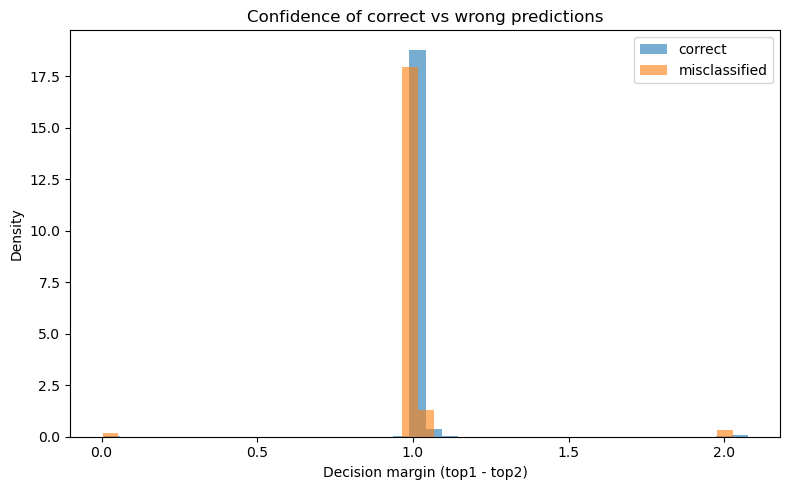

In [19]:
fig, ax = plt.subplots(figsize=(8,5))
ax.hist(err_df[err_df.correct].margin, bins=40, alpha=0.6, label='correct', density=True)
ax.hist(err_df[~err_df.correct].margin, bins=40, alpha=0.6, label='misclassified', density=True)
ax.set_xlabel('Decision margin (top1 - top2)')
ax.set_ylabel('Density')
ax.set_title('Confidence of correct vs wrong predictions')
ax.legend()
plt.tight_layout()
plt.show()

## Confusion matrix


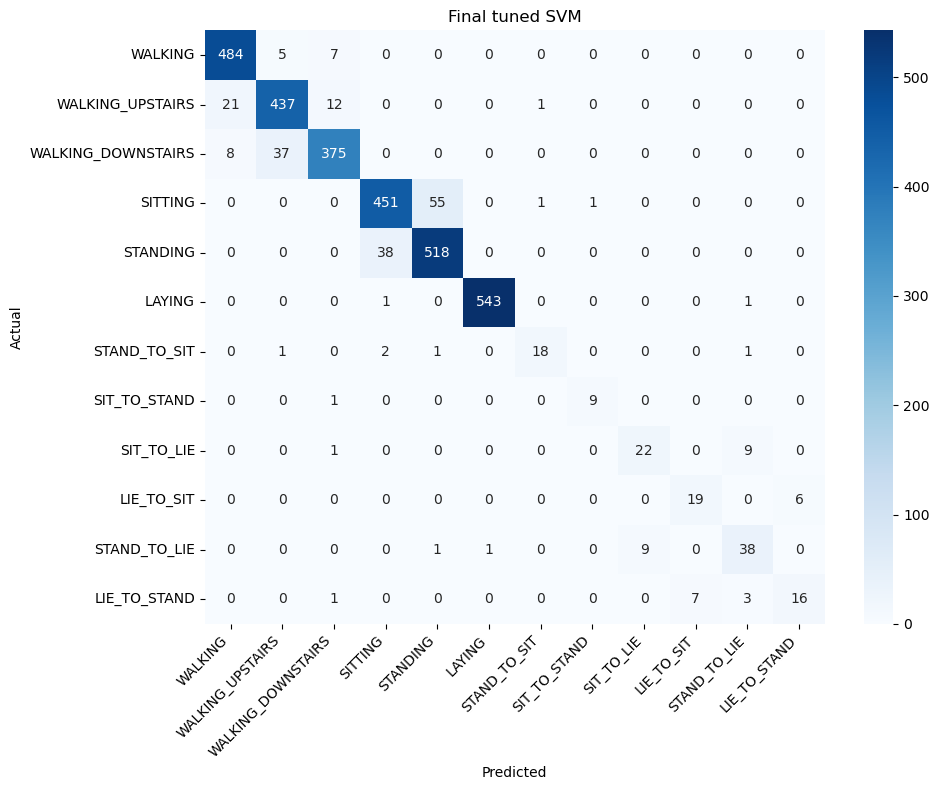

In [20]:
cm = confusion_matrix(y_test_m, y_pred, labels=class_order)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_order, yticklabels=class_order)
plt.ylabel('Actual'); plt.xlabel('Predicted'); plt.title('Final tuned SVM')
plt.xticks(rotation=45, ha='right'); plt.tight_layout(); plt.show()

## 2D PCA projection of test set

Visual justification for why SITTING/STANDING overlap


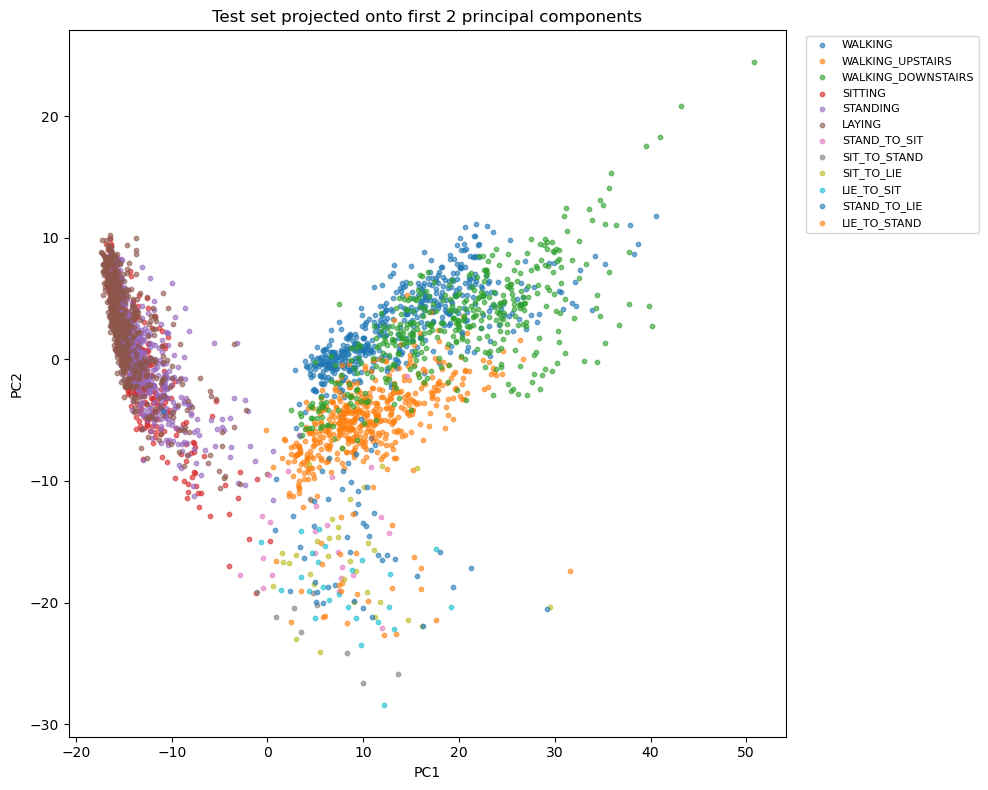

In [21]:
# reuse the scaler/pca fit earlier; take first 2 components
Xte_2d = Xte_p[:, :2]

plt.figure(figsize=(10, 8))
for cls in class_order:
    m = y_test_m.values == cls
    plt.scatter(Xte_2d[m, 0], Xte_2d[m, 1], s=10, label=cls, alpha=0.6)
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)
plt.title('Test set projected onto first 2 principal components')
plt.tight_layout(); plt.show()

## Linear SVM contrast

Fast + interpretable baseline on full 561 features.


In [22]:
lin = Pipeline([
    ('sc', StandardScaler()),
    ('svm', LinearSVC(C=1, class_weight='balanced', max_iter=5000, random_state=RNG))
]).fit(X_train, y_train_m)
y_lin = lin.predict(X_test)
print('Linear SVM (raw 561):')
print(f'  macro F1 = {f1_score(y_test_m, y_lin, average="macro"):.4f}')
print(f'  acc      = {(y_lin == y_test_m).mean():.4f}')

Linear SVM (raw 561):
  macro F1 = 0.8478
  acc      = 0.9472


## Save results for the group comparison table


In [23]:
ablation.to_csv('svm_ablation.csv', index=False)
pd.DataFrame({
    'model': ['SVM-RBF (final)', 'SVM-Linear (raw)'],
    'macro_f1': [f1_score(y_test_m, y_pred, average='macro'),
                 f1_score(y_test_m, y_lin, average='macro')],
    'weighted_f1': [f1_score(y_test_m, y_pred, average='weighted'),
                    f1_score(y_test_m, y_lin, average='weighted')],
    'accuracy': [(y_pred == y_test_m).mean(), (y_lin == y_test_m).mean()],
}).to_csv('svm_final_summary.csv', index=False)
print('Saved svm_ablation.csv and svm_final_summary.csv')

Saved svm_ablation.csv and svm_final_summary.csv


## Macro AUC-ROC and MIoU


In [28]:
# Macro AUC-ROC
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize

# train the best config fresh (raw 561, RBF, balanced, C=10, gamma=scale)
best_raw = Pipeline([
    ('sc', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced',
                random_state=RNG, decision_function_shape='ovr'))
]).fit(X_train, y_train_m)

y_scores = best_raw.decision_function(X_test)
col_order = [list(best_raw.named_steps['svm'].classes_).index(c) for c in class_order]
y_scores_aligned = y_scores[:, col_order]

y_test_bin = label_binarize(y_test_m, classes=class_order)
macro_auc = roc_auc_score(y_test_bin, y_scores_aligned, multi_class='ovr', average='macro')
print(f'Macro AUC-ROC: {macro_auc:.3f}')

# Cell 2: MIoU
y_pred_raw = best_raw.predict(X_test)
cm = confusion_matrix(y_test_m, y_pred_raw, labels=class_order)

ious = []
for i in range(len(class_order)):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    iou = tp / (tp + fp + fn) if (tp + fp + fn) > 0 else 0
    ious.append(iou)
    print(f'{class_order[i]:>25s}: IoU = {iou:.4f}')

miou = np.mean(ious)
print(f'\nMIoU: {miou:.3f}')

Macro AUC-ROC: 0.985
                  WALKING: IoU = 0.9363
         WALKING_UPSTAIRS: IoU = 0.8994
       WALKING_DOWNSTAIRS: IoU = 0.8817
                  SITTING: IoU = 0.8596
                 STANDING: IoU = 0.8854
                   LAYING: IoU = 0.9927
             STAND_TO_SIT: IoU = 0.7200
             SIT_TO_STAND: IoU = 0.8182
               SIT_TO_LIE: IoU = 0.5116
               LIE_TO_SIT: IoU = 0.6562
             STAND_TO_LIE: IoU = 0.5714
             LIE_TO_STAND: IoU = 0.5161

MIoU: 0.771
